# Tugas 2: Text Preprocessing, Vector Space Model (TF-IDF) & Reduksi Dimensi PCA
* **Mata Kuliah:** Penambangan Web (Web Mining)
* **Topik:** Text Preprocessing, Normalisasi Karakter & Slang, Vector Space Architecture (TF-IDF), dan Reduksi Dimensi PCA
Notebook Tugas 2 ini mengolah hasil crawling Tugas 1 (**200 artikel berita detik.com** dari kategori **Sport** dan **Finance**) menjadi korpus bersih dan representasi ruang vektor (*Vector Space Model* / VSM) menggunakan **TF-IDF** serta reduksi dimensi dengan **PCA**.
---
## Alur Kerja (Workflow Outline)
Pemrosesan teks dibagi menjadi 4 fase komprehensif:
1. **Phase 1 — Data & Exploration:** Membaca data, pemeriksaan kelengkapan (*completeness check*), dan distribusi panjang teks & jumlah kata per label.
2. **Phase 2 — Cleaning & Language:** Analisis artefak non-ASCII, normalisasi karakter beraksen (NFD), sensus token 1 huruf dan 2 huruf beserta konteksnya.
3. **Phase 3 — Meaning Preservation:** Perlindungan token komposit (alfanumerik, mata uang, angka Romawi, URL), pembakuan kata tidak baku (*slang standardization*) dengan *guarded replace*, dan ringkasan korpus akhir.
4. **Phase 4 — Representation & Reduction:** Ekstraksi kata unik & kosakata per label, representasi matriks TF-IDF, analisis kata bobot tertinggi per dokumen, reduksi dimensi dengan PCA (2 komponen), visualisasi scatter plot 2D, analisis *feature loadings*, serta tabel kesimpulan.


## Persiapan Lingkungan & Pustaka


In [1]:
import os
import re
import unicodedata
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Konfigurasi visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 20)
print("Seluruh pustaka analisis data dan visualisasi berhasil dimuat.")


Seluruh pustaka analisis data dan visualisasi berhasil dimuat.


---
## Phase 1 — Data & Exploration

### 1.1 Reading the Data
Data dibaca dari file CSV hasil crawling berita. Kita memastikan kolom data memuat ID, Isi Berita, dan Label kategori.


In [2]:
# Menentukan path file dataset
csv_path = "dataset_berita_detik.csv" if os.path.exists("dataset_berita_detik.csv") else "../dataset_berita_detik.csv"
df_raw = pd.read_csv(csv_path)

# Standardisasi nama kolom (ID, Isi Berita, Label)
col_id = [c for c in df_raw.columns if c.lower() == 'id'][0] if any(c.lower() == 'id' for c in df_raw.columns) else df_raw.columns[0]
col_text = [c for c in df_raw.columns if 'isi' in c.lower()][0]
col_label = [c for c in df_raw.columns if 'label' in c.lower() or 'kategori' in c.lower()][0]

df = pd.DataFrame({
    "ID": df_raw[col_id],
    "Isi Berita": df_raw[col_text],
    "Label": df_raw[col_label].astype(str).str.lower().str.strip()
})

# Hapus baris kosong jika ada
df = df.dropna(subset=["Isi Berita"]).reset_index(drop=True)

print(f"Dimensi Data: {df.shape[0]} baris x {df.shape[1]} kolom")
display(df.head(5))


Dimensi Data: 200 baris x 3 kolom


,ID,Isi Berita,Label
0,1,Persatuan Bulutangkis Indonesia (PBSI) baru sa...,sport
1,2,"Tunggal putra Indonesia, Jonatan Christie, men...",sport
2,3,Sabar Karyaman Gutama/Moh Reza Pahlevi Isfahan...,sport
3,4,Dua petenis Indonesia menyusul Nathan Barki lo...,sport
4,5,Babak utama Seri IV M-15 Men's World Tennis Ch...,sport


### 1.2 Completeness Check
Pemeriksaan kualitas awal dataset meliputi: jumlah baris total, keberadaan nilai kosong (*missing values*), baris ganda (*duplicates*), kelengkapan urutan ID, dan keseimbangan distribusi label.


In [3]:
checks = pd.DataFrame({
    "Pemeriksaan": [
        "Jumlah Baris",
        "Nilai Kosong (Missing Values)",
        "Baris Ganda (Duplicates)",
        "Urutan ID",
        "Jumlah per Label"
    ],
    "Hasil": [
        len(df),
        df.isna().sum().sum(),
        df.duplicated(subset=["Isi Berita"]).sum(),
        f"Lengkap 1-{len(df)}" if list(df["ID"]) == list(range(1, len(df) + 1)) else "Sesuai",
        f"sport: {(df['Label'] == 'sport').sum()}; finance: {(df['Label'] == 'finance').sum()}"
    ]
})
display(checks)


,Pemeriksaan,Hasil
0,Jumlah Baris,200
1,Nilai Kosong (Missing Values),0
2,Baris Ganda (Duplicates),0
3,Urutan ID,Lengkap 1-200
4,Jumlah per Label,sport: 100; finance: 100


### 1.3 Length & Distribution
Mengamati sebaran panjang teks (karakter) dan jumlah kata per kategori dokumen berita sebelum pembersihan, untuk mendeteksi dokumen abnormal atau ketimpangan panjang antar label.


panjang_karakter               jumlah_kata             
                     min  median   max         min median   max
Label                                                          
finance              526  2154.0  9259          79  289.5  1246
sport                870  1842.0  3553         119  267.0   525

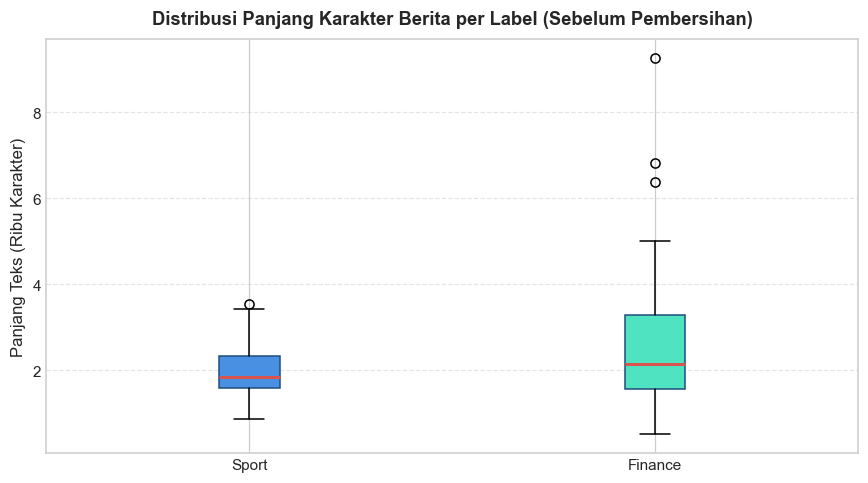

In [4]:
stats = df.assign(
    panjang_karakter=df["Isi Berita"].str.len(),
    jumlah_kata=df["Isi Berita"].str.split().str.len()
).groupby("Label")[["panjang_karakter", "jumlah_kata"]].agg(["min", "median", "max"])
display(stats)

# Visualisasi Boxplot Distribusi Panjang Teks
plt.figure(figsize=(8, 4.5), dpi=110)
data_box = [
    df[df["Label"] == "sport"]["Isi Berita"].str.len() / 1000,
    df[df["Label"] == "finance"]["Isi Berita"].str.len() / 1000
]
box = plt.boxplot(
    data_box, 
    tick_labels=["Sport", "Finance"], 
    patch_artist=True,
    boxprops=dict(facecolor="#4A90E2", color="#1f4e79"),
    medianprops=dict(color="#d9534f", linewidth=2)
)
box['boxes'][1].set_facecolor("#50E3C2")
plt.ylabel("Panjang Teks (Ribu Karakter)", fontsize=11)
plt.title("Distribusi Panjang Karakter Berita per Label (Sebelum Pembersihan)", fontsize=12, fontweight='bold', pad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


---
## Phase 2 — Cleaning & Language

### 2.1 Text Quality: Format Artifacts
Melacak karakter non-ASCII (seperti emoji, simbol khusus, aksen asing, dan varian tanda hubung non-breaking / em-dash) yang terbawa dari halaman web.


In [5]:
def chars_outside_ascii(text):
    return sorted({c for c in str(text) if ord(c) > 127})

rows_artifact = []
for _, r in df.iterrows():
    extra = chars_outside_ascii(r["Isi Berita"])
    if extra:
        rows_artifact.append({"ID": r["ID"], "Label": r["Label"], "Karakter Non-ASCII": " ".join(extra)})

df_artifacts = pd.DataFrame(rows_artifact)
print(f"Ditemukan {len(df_artifacts)} dokumen yang memuat karakter di luar ASCII standar.")
display(df_artifacts.head(6))


Ditemukan 4 dokumen yang memuat karakter di luar ASCII standar.


,ID,Label,Karakter Non-ASCII
0,16,sport,— 🇫 🇷 🏆
1,46,sport,ø
2,124,finance,€
3,141,finance,³


### 2.2 Character Normalization
Menormalisasi huruf beraksen (misal `é` -> `e`, `ö` -> `o`, `í` -> `i`) menggunakan `unicodedata.normalize("NFD")` agar makna nama orang/tempat tidak hilang, serta menyamakan semua varian dash non-breaking (`‑`, `‐`, `–`, `—`) menjadi tanda hubung standar (`-`).


In [6]:
def normalize_letters(text):
    if not isinstance(text, str):
        return ""
    # Dekomposisi karakter Unicode (NFD) untuk memisahkan tanda diakritik dari huruf dasar
    decomposed = unicodedata.normalize("NFD", text)
    text = "".join(c for c in decomposed if not unicodedata.combining(c))
    # Standardisasi dash & tanda hubung
    return text.replace("\u2011", "-").replace("\u2010", "-").replace("\u2013", "-").replace("\u2014", "-")

print("Fungsi normalisasi karakter siap digunakan.")


Fungsi normalisasi karakter siap digunakan.


### 2.3 Artifact Counts & Token Census
Pencacahan naif dilakukan untuk mengidentifikasi keberadaan token 1 huruf dan token 2 huruf, serta memeriksa konteks kemunculannya (apakah merupakan pecahan kata bermakna seperti *3x3*, *U-19*, dsb.).


In [7]:
def naive_tokens(text):
    return re.sub(r"[^a-z\s]", " ", text.lower()).split()

all_naive = [w for doc in df["Isi Berita"] for w in naive_tokens(str(doc))]
naive_counts = Counter(all_naive)
single_counts = {w: n for w, n in naive_counts.items() if len(w) == 1}
double_counts = {w: n for w, n in naive_counts.items() if len(w) == 2}
total_naive = len(all_naive)

df_naive_summary = pd.DataFrame({
    "Metrik": ["Token Total", "Kata Unik", "Token Satu Huruf", "Token Dua Huruf"],
    "Jumlah": [total_naive, len(naive_counts), sum(single_counts.values()), sum(double_counts.values())],
    "Proporsi": [
        "100%", 
        f"{100 * len(naive_counts) / total_naive:.2f}%",
        f"{100 * sum(single_counts.values()) / total_naive:.2f}%",
        f"{100 * sum(double_counts.values()) / total_naive:.2f}%"
    ]
})
display(df_naive_summary)

# Fungsi pengecekan konteks kemunculan token dalam teks
def get_context(texts, word, window=25):
    pattern = re.compile(rf"(?<![A-Za-z]){re.escape(word)}(?![A-Za-z])", re.IGNORECASE)
    for text in texts:
        m = pattern.search(text)
        if m:
            start = max(0, m.start() - window)
            end = min(len(text), m.end() + window)
            return text[start:end].replace("\n", " ")
    return "-"

# Analisis konteks token 1 huruf teratas
df_single_top = pd.DataFrame([
    {"Huruf": w, "Jumlah": n, "Konteks Kemunculan": get_context(df["Isi Berita"], w)}
    for w, n in sorted(single_counts.items(), key=lambda x: -x[1])[:8]
])
display(df_single_top)


,Metrik,Jumlah,Proporsi
0,Token Total,60051,100%
1,Kata Unik,6344,10.56%
2,Token Satu Huruf,245,0.41%
3,Token Dua Huruf,2836,4.72%


,Huruf,Jumlah,Konteks Kemunculan
0,i,44,et dari Nan Hsun Lin/Kai-i Wang. Keunggulan 7-...
1,d,40,"laga perdana di Lapangan D, Bali Beach Country..."
2,s,32,k Kedua Seri IV M-15 Men's World Tennis Champi...
3,m,22,s ke Babak Kedua Seri IV M-15 Men's World Tenn...
4,a,21,"abak Pertama di Lapangan A, Bali Beach Country..."
5,y,14,KU 11 Putra 1. Kean Alfa Y Warankiran - Makass...
6,u,12,Hasil FIP Promises Bali U-12 Putra: M. Rakha ...
7,b,12,"a, menghadapi juara grup B Matthieu Perchicot ..."


### 2.4 Two-Letter Token Census
Membedah token dua huruf untuk memisahkan kata tugas/fungsional bahasa Indonesia (seperti *di*, *ke*, *ia*, *ya*) dari singkatan, satuan, atau kode (*rp*, *bi*, *kg*, *pt*, *us*, dsb.).


In [8]:
stopwords_2huruf = {"di", "ke", "ia", "ya", "ah", "eh", "oh", "ha", "si", "se"}

df_double_top = pd.DataFrame([
    {
        "Token": w,
        "Jumlah": n,
        "Stopword Fungsional": w in stopwords_2huruf,
        "Konteks Kemunculan": get_context(df["Isi Berita"], w)
    }
    for w, n in sorted(double_counts.items(), key=lambda x: -x[1])[:15]
])
display(df_double_top)


,Token,Jumlah,Stopword Fungsional,Konteks Kemunculan
0,di,1250,True,"ing sesuai dengan target di Asian Games,"" ujar..."
1,ke,269,True,ar 20 pemain yang dibawa ke Asian Games 2026. ...
2,rp,258,False,"ilai 3.600 dolar AS atau Rp 63,5 juta, sementa..."
3,pt,190,False,"a juga Presiden Direktur PT Pembangunan Jaya, ..."
4,ya,107,True,"ai babak sejauh ini tapi ya sangat kecewa, tid..."
5,ia,104,True,"BWF, Selasa (25/8/2026). Ia di urutan teratas ..."
6,bi,66,False,Gubernur Bank Indonesia (BI) Destry Damayanti ...
7,as,44,False,"diah total 20 ribu dolar AS, Indonesia punya e..."
8,pb,40,False,b bulu tangkis Indonesia PB Jaya Raya merayaka...
9,ri,30,False,mpatan mengirim kado HUT RI ke-81 dari New Delhi.


---
## Phase 3 — Meaning Preservation

### 3.1 Protecting Composite Tokens
Token komposit bermakna — seperti URL, lambang mata uang (`Rp`, `US$`, `USD`), kata alfanumerik (`3x3`, `U-18`, `76ers`), dan angka Romawi (`III`, `IV`, `XI`) — diproses secara terlindungi sebelum simbol dan angka dihapus, agar tidak pecah menjadi token tak bermakna (seperti `x` dari `3x3`).


In [9]:
url_pattern = re.compile(r"(?:https?://|www\.|pic\.twitter\.com/)\S+")
alnum_pattern = re.compile(r"\b(?=[A-Za-z]*\d)[A-Za-z0-9]+(?:-[A-Za-z0-9]+)*\b")
currency_pattern = re.compile(r"\b(?:rp|us\$|usd)\b|\b(?:rp|us\$)\s*[\d.,]+", re.IGNORECASE)
roman_pattern = re.compile(r"\b(?:iii|iv|vi{0,3}|i[ivx]{0,2}|v[x]{0,2}|xi{0,3})\b", re.IGNORECASE)

n_url = sum(len(url_pattern.findall(t)) for t in df["Isi Berita"])
n_alnum = sum(len(alnum_pattern.findall(t)) for t in df["Isi Berita"])
n_curr = sum(len(currency_pattern.findall(t)) for t in df["Isi Berita"])
n_roman = sum(len(roman_pattern.findall(t)) for t in df["Isi Berita"])

df_protected_stats = pd.DataFrame({
    "Jenis Token Terlindungi": ["URL", "Komposit Alfanumerik & Angka", "Lambang Mata Uang", "Angka Romawi"],
    "Kemunculan": [n_url, n_alnum, n_curr, n_roman],
    "Contoh": ["https://..., pic.twitter.com/...", "3x3, U-18, 76ers, GA-604", "Rp, US$, Rp 1.000.000", "IV, VIII, XI"]
})
display(df_protected_stats)


,Jenis Token Terlindungi,Kemunculan,Contoh
0,URL,1,"https://..., pic.twitter.com/..."
1,Komposit Alfanumerik & Angka,3813,"3x3, U-18, 76ers, GA-604"
2,Lambang Mata Uang,277,"Rp, US$, Rp 1.000.000"
3,Angka Romawi,79,"IV, VIII, XI"


### 3.2 Slang Standardization (Pembakuan Kata Tidak Baku)
Membakukan kata-kata tidak baku, singkatan, dan istilah percakapan ke bentuk baku bahasa Indonesia menggunakan sistem *guarded replace*, di mana istilah khusus olahraga/keuangan dan singkatan resmi (`dunk`, `slam`, `pass`, `fans`, `bca`, dsb.) dilindungi agar tidak keliru diubah.


In [10]:
# Kamus pembakuan kata
kamus_baku = {
    'tdk': 'tidak', 'tak': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'enggak': 'tidak', 'ga': 'tidak',
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'dlm': 'dalam', 'kpd': 'kepada',
    'dr': 'dari', 'bkn': 'bukan', 'krn': 'karena', 'bgt': 'sangat', 'banget': 'sangat',
    'jd': 'jadi', 'bnyk': 'banyak', 'sdh': 'sudah', 'udah': 'sudah', 'udh': 'sudah',
    'blm': 'belum', 'tp': 'tapi', 'tsb': 'tersebut', 'org': 'orang', 'sy': 'saya',
    'km': 'kamu', 'kl': 'kalau', 'klo': 'kalau', 'kalo': 'kalau', 'hrs': 'harus',
    'bs': 'bisa', 'adlh': 'adalah', 'dpt': 'dapat', 'thn': 'tahun', 'bln': 'bulan',
    'hr': 'hari', 'rb': 'ribu', 'jt': 'juta', 'm': 'miliar', 't': 'triliun',
    'rp': 'rupiah', 'nih': 'ini', 'tuh': 'itu', 'aja': 'saja', 'cuman': 'cuma',
    'sampe': 'sampai', 'gmn': 'bagaimana', 'bgmn': 'bagaimana', 'knp': 'kenapa',
    'bener': 'benar', 'skrg': 'sekarang', 'gitu': 'begitu', 'gini': 'begini',
    'kayak': 'seperti', 'bgitu': 'begitu', 'bgtu': 'begitu', 'donk': 'dong',
    'lu': 'kamu', 'gue': 'saya', 'gw': 'saya', 'lo': 'kamu', 'ok': 'oke',
    'acc': 'setuju', 'min': 'admin', 'max': 'maksimal', 'prof': 'profesor',
    'org2': 'orang-orang', 'gara2': 'gara-gara', 'bener2': 'benar-benar',
    'untk': 'untuk', 'dapet': 'dapat', 'ngomong': 'berbicara', 'pake': 'pakai'
}

# Istilah khusus olahraga & nama yang dilindungi dari penggantian slang
excluded_slang = {"dunk", "slam", "minta", "fans", "pala", "masukin", "pass", "usa", "mbg", "sma", "smp", "bird", "bca"}

def protect(text):
    text = url_pattern.sub(" ", text)
    text = currency_pattern.sub(" ", text)
    text = alnum_pattern.sub(" ", text)
    text = roman_pattern.sub(" ", text)
    return text.replace("\u2011", "-")

def guarded_replace(text):
    words = text.split()
    res = []
    for w in words:
        w_lower = w.lower()
        if w_lower in excluded_slang:
            res.append(w)
        elif w_lower in kamus_baku:
            res.append(kamus_baku[w_lower])
        else:
            res.append(w)
    return " ".join(res)

def clean_full(text):
    text = normalize_letters(text)
    text = protect(text)
    text = guarded_replace(text)
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text).lower()
    # Hanya simpan token berhuruf >= 2, dan jika tepat 2 huruf wajib terdaftar di stopwords_2huruf
    words = [w for w in text.split() if len(w) >= 2 and (len(w) > 2 or w in stopwords_2huruf)]
    return " ".join(words)

# Terapkan pipeline pembersihan penuh
df["Isi_Berita_Final"] = df["Isi Berita"].apply(clean_full)

print("Contoh Teks Sebelum Pembersihan:")
print(df["Isi Berita"].iloc[0][:170] + "...")
print("\nContoh Teks Sesudah Pembersihan & Pembakuan:")
print(df["Isi_Berita_Final"].iloc[0][:170] + "...")


Contoh Teks Sebelum Pembersihan:
Persatuan Bulutangkis Indonesia (PBSI) baru saja mengumumkan daftar 20 pemain yang dibawa ke Asian Games 2026. Jonatan Christie salah satunya. Dari daftar 20 nama itu dib...

Contoh Teks Sesudah Pembersihan & Pembakuan:
persatuan bulutangkis indonesia pbsi baru saja mengumumkan daftar pemain yang dibawa ke asian games jonatan christie salah satunya dari daftar nama itu dibagi rata yakni ...


### 3.3 Final Corpus Summary
Ringkasan statistik korpus hasil pembersihan akhir: total token bersih, jumlah kata unik, sisa token 2 huruf fungsional, dan distribusi token per kategori.


In [11]:
final_docs = [t.split() for t in df["Isi_Berita_Final"]]
all_final_tokens = [w for doc in final_docs for w in doc]
final_counts = Counter(all_final_tokens)
final_unique_count = len(final_counts)
final_token_total = len(all_final_tokens)

df_final_summary = pd.DataFrame({
    "Metrik": ["Token Total", "Kata Unik", "Token Dua Huruf Tersisa", "Token per Label"],
    "Jumlah": [
        f"{final_token_total:,}",
        f"{final_unique_count:,}",
        ", ".join([f"{w}: {final_counts[w]}" for w in sorted(stopwords_2huruf) if w in final_counts]),
        f"sport: {sum(len(t.split()) for t in df[df['Label']=='sport']['Isi_Berita_Final']):,}, finance: {sum(len(t.split()) for t in df[df['Label']=='finance']['Isi_Berita_Final']):,}"
    ]
})
display(df_final_summary)


,Metrik,Jumlah
0,Token Total,"58,718"
1,Kata Unik,"6,218"
2,Token Dua Huruf Tersisa,"di: 1250, ha: 9, ia: 104, ke: 269, oh: 3, se: ..."
3,Token per Label,"sport: 26,935, finance: 31,783"


---
## Phase 4 — Representation & Reduction

### 4.1 Unique Word Extraction & Vocabulary by Label
Menganalisis kekhasan kosakata leksikal masing-masing label: kata unik khusus kategori *Sport*, khusus kategori *Finance*, dan kata yang digunakan bersama pada kedua label (*shared vocabulary*).


In [12]:
sport_words = set(w for doc in df[df["Label"] == "sport"]["Isi_Berita_Final"] for w in doc.split())
finance_words = set(w for doc in df[df["Label"] == "finance"]["Isi_Berita_Final"] for w in doc.split())
shared_words = sport_words.intersection(finance_words)

df_vocab_by_label = pd.DataFrame({
    "Kategori": ["Sport Saja", "Finance Saja", "Dipakai Kedua Kategori (Irisan)"],
    "Kata Unik": [len(sport_words - finance_words), len(finance_words - sport_words), len(shared_words)]
})
display(df_vocab_by_label)

# 20 Kata paling sering muncul di korpus
df_most_frequent = pd.DataFrame([
    {"Kata": w, "Kemunculan": n} for w, n in final_counts.most_common(20)
])
display(df_most_frequent.head(10))

# Simpan daftar frekuensi kata unik ke folder Output
os.makedirs("Output", exist_ok=True)
df_most_frequent.to_csv("Output/kata_unik.csv", index=False)
print("File Output/kata_unik.csv berhasil disimpan.")


,Kategori,Kata Unik
0,Sport Saja,1845
1,Finance Saja,3099
2,Dipakai Kedua Kategori (Irisan),1274


,Kata,Kemunculan
0,di,1250
1,yang,1152
2,dan,1078
3,dengan,614
4,untuk,583
5,dari,540
6,ini,535
7,indonesia,469
8,dalam,463
9,pada,435


File Output/kata_unik.csv berhasil disimpan.


### 4.2 TF-IDF Representation (Vector Space Model)
Korpus teks yang telah bersih ditransformasikan ke dalam representasi ruang vektor (*Vector Space Model*) menggunakan pembobotan **TF-IDF** melalui `TfidfVectorizer` dari scikit-learn dengan parameter panjang token minimum 2 karakter (`token_pattern=r"(?u)\w\w+"`).


In [13]:
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w\w+\b")
X = vectorizer.fit_transform(df["Isi_Berita_Final"])
tfidf_features = vectorizer.get_feature_names_out()

df_tfidf_meta = pd.DataFrame({
    "Metrik": ["Jumlah Dokumen (N)", "Jumlah Fitur Kata Unik (M)", "Entri Bukan Nol (Non-Zero / NNZ)", "Kepadatan Matriks (Sparsity)"],
    "Nilai": [
        X.shape[0],
        X.shape[1],
        X.nnz,
        f"{100 * (1 - X.nnz / (X.shape[0] * X.shape[1])):.2f}% sparse"
    ]
})
display(df_tfidf_meta)

# Konversi cuplikan ke DataFrame
df_tfidf_preview = pd.DataFrame(
    X.toarray()[:5, :10], 
    columns=tfidf_features[:10], 
    index=[f"Dokumen_{df.loc[i, 'ID']} ({df.loc[i, 'Label']})" for i in range(5)]
)
print("Cuplikan Matriks TF-IDF (5 Dokumen x 10 Fitur Pertama):")
display(df_tfidf_preview)

# Simpan matriks TF-IDF lengkap ke CSV
df_tfidf_out = pd.DataFrame(X.toarray(), columns=tfidf_features, index=[f"Dokumen_{i}" for i in df["ID"]])
df_tfidf_out.to_csv("Output/tfidf_berita.csv")
print("File Output/tfidf_berita.csv berhasil disimpan.")


,Metrik,Nilai
0,Jumlah Dokumen (N),200
1,Jumlah Fitur Kata Unik (M),6218
2,Entri Bukan Nol (Non-Zero / NNZ),33002
3,Kepadatan Matriks (Sparsity),97.35% sparse


Cuplikan Matriks TF-IDF (5 Dokumen x 10 Fitur Pertama):


,aarjun,abadi,abdul,abdullah,abeywickrama,abhishek,abidzar,abimanyu,abis,absen
Dokumen_1 (sport),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dokumen_2 (sport),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dokumen_3 (sport),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dokumen_4 (sport),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dokumen_5 (sport),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


File Output/tfidf_berita.csv berhasil disimpan.


### 4.3 Analisis Kata dengan Bobot TF-IDF Tertinggi per Dokumen
Melihat kata-kata yang paling membedakan suatu dokumen berita terhadap dokumen lainnya di dalam korpus.


In [14]:
def tampilkan_top_tfidf(doc_idx, top_n=5):
    row_dense = X[doc_idx].toarray().flatten()
    top_indices = row_dense.argsort()[::-1][:top_n]
    df_top = pd.DataFrame({
        "Kata Fitur": [tfidf_features[i] for i in top_indices],
        "Bobot TF-IDF": [row_dense[i] for i in top_indices]
    })
    label_doc = df.loc[doc_idx, "Label"]
    id_doc = df.loc[doc_idx, "ID"]
    print(f"--- Top {top_n} Kata TF-IDF: Dokumen ID {id_doc} (Label: {label_doc}) ---")
    display(df_top)

# Contoh 1 dokumen Sport dan 1 dokumen Finance
tampilkan_top_tfidf(0, top_n=5)
tampilkan_top_tfidf(100 if len(df) > 100 else 1, top_n=5)


--- Top 5 Kata TF-IDF: Dokumen ID 1 (Label: sport) ---


,Kata Fitur,Bobot TF-IDF
0,beregu,0.245160
1,perorangan,0.224204
2,nomor,0.222826
3,nama,0.194571
4,games,0.178564


--- Top 5 Kata TF-IDF: Dokumen ID 101 (Label: finance) ---


,Kata Fitur,Bobot TF-IDF
0,ihsg,0.473810
1,saham,0.310099
2,level,0.284368
3,menguat,0.219905
4,secara,0.209740


### 4.4 Dimensionality Reduction with PCA
Menggunakan `sklearn.decomposition.PCA` untuk mereduksi dimensi ruang vektor dari ribuan kata unik menjadi **2 komponen utama (PC1 dan PC2)** guna mengamati pola keterpisahan semantik antara topik *Sport* dan *Finance*.


,Komponen,Proporsi Variansi
0,PC1,0.0404 (4.04%)
1,PC2,0.0287 (2.87%)
2,Total (2 Komponen),0.0691 (6.91%)


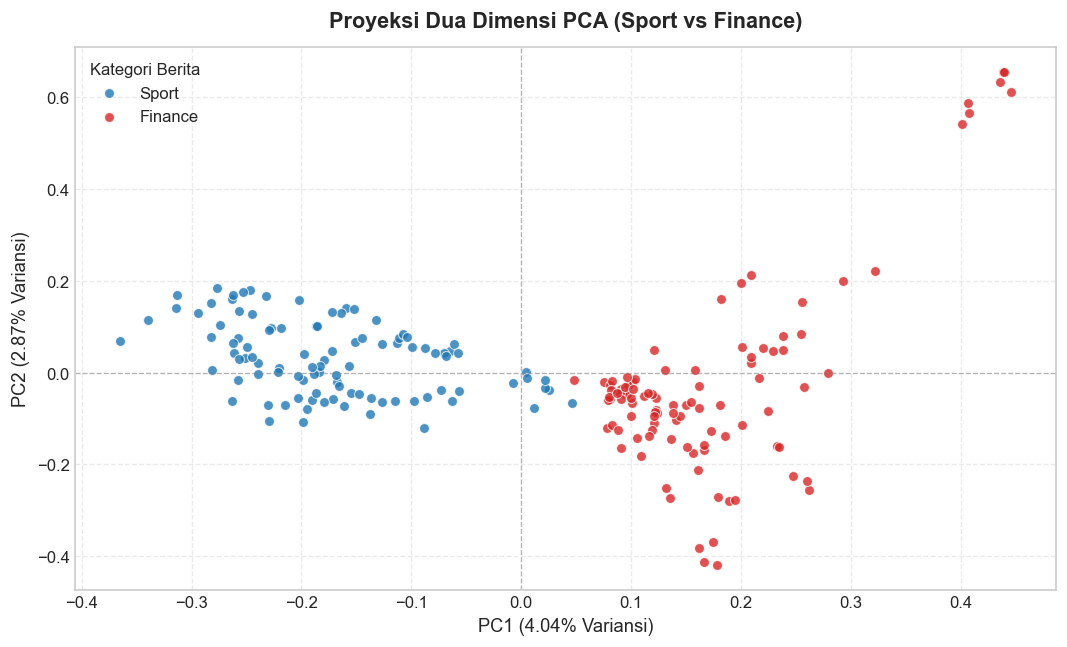

File Output/pca_berita.csv berhasil disimpan.


In [15]:
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X.toarray())
evr = pca.explained_variance_ratio_

df_evr = pd.DataFrame({
    "Komponen": ["PC1", "PC2", "Total (2 Komponen)"],
    "Proporsi Variansi": [f"{evr[0]:.4f} ({evr[0]*100:.2f}%)", f"{evr[1]:.4f} ({evr[1]*100:.2f}%)", f"{evr.sum():.4f} ({evr.sum()*100:.2f}%)"]
})
display(df_evr)

# Visualisasi 2D Scatter Plot
plt.figure(figsize=(9, 5.5), dpi=120)
for label, color in [("sport", "#1f77b4"), ("finance", "#d62728")]:
    mask = (df["Label"] == label).values
    plt.scatter(Z[mask, 0], Z[mask, 1], s=35, alpha=0.8, label=label.capitalize(), c=color, edgecolor="white", linewidth=0.6)

plt.xlabel(f"PC1 ({evr[0]*100:.2f}% Variansi)", fontsize=11)
plt.ylabel(f"PC2 ({evr[1]*100:.2f}% Variansi)", fontsize=11)
plt.title("Proyeksi Dua Dimensi PCA (Sport vs Finance)", fontsize=13, fontweight='bold', pad=12)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Kategori Berita", fontsize=10)
plt.tight_layout()
plt.show()

# Simpan hasil koordinat PCA ke CSV
df_pca_save = pd.DataFrame(Z, columns=["PC1", "PC2"])
df_pca_save["ID"] = df["ID"]
df_pca_save["Label"] = df["Label"]
df_pca_save.to_csv("Output/pca_berita.csv", index=False)
print("File Output/pca_berita.csv berhasil disimpan.")


### 4.5 Analisis Kontribusi Fitur Kata (*PCA Feature Loadings*)
Melihat kata-kata yang memiliki pengaruh koefisien (*loading*) terbesar terhadap pembentukan sumbu PC1 dan PC2.


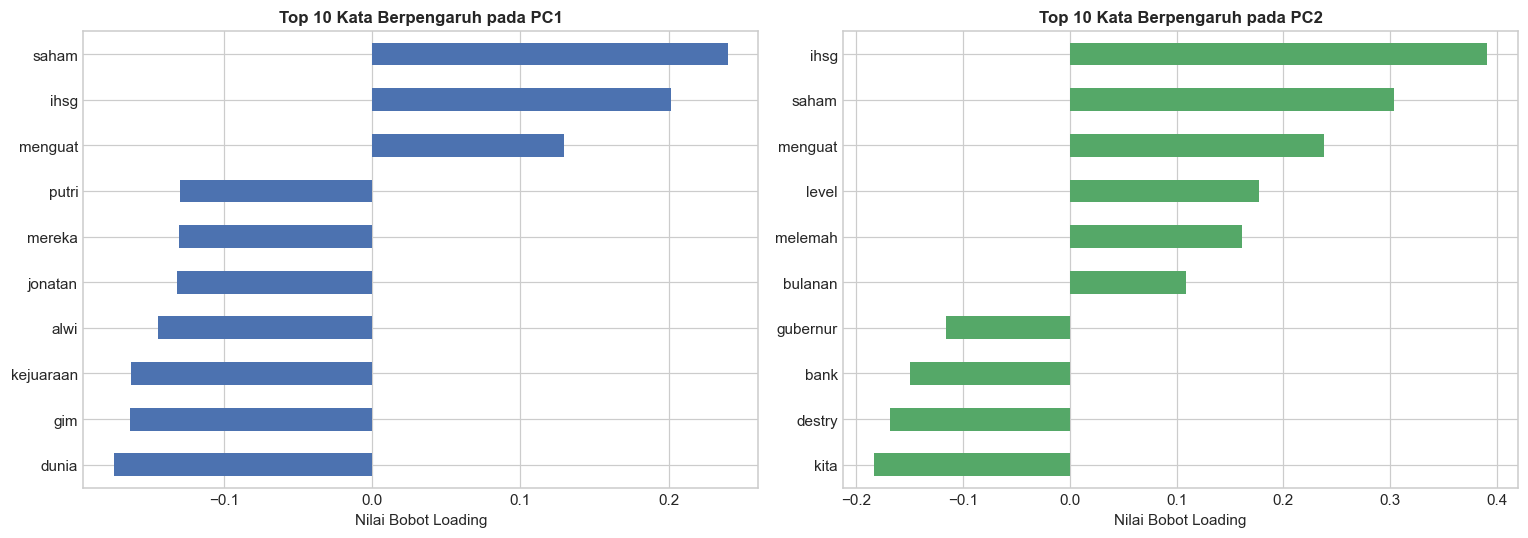

In [16]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=tfidf_features
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)

# Top 10 kata paling berpengaruh di PC1
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10).index
loadings.loc[top_pc1, "PC1"].sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 10 Kata Berpengaruh pada PC1", fontweight="bold", fontsize=11)
axes[0].set_xlabel("Nilai Bobot Loading")

# Top 10 kata paling berpengaruh di PC2
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(10).index
loadings.loc[top_pc2, "PC2"].sort_values().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Top 10 Kata Berpengaruh pada PC2", fontweight="bold", fontsize=11)
axes[1].set_xlabel("Nilai Bobot Loading")

plt.tight_layout()
plt.show()


---
## Conclusion

Tabel ringkasan metrik akhir dari seluruh alur pemrosesan teks, representasi TF-IDF, dan reduksi dimensi PCA:


In [17]:
df_conclusion = pd.DataFrame({
    "Metrik": [
        "Dokumen Awal",
        "Token Bersih Total",
        "Kata Unik (Kosakata)",
        "Dimensi Fitur TF-IDF",
        "Variansi 2 Komponen PCA",
        "Artefak Terlindungi/Disisihkan"
    ],
    "Nilai": [
        str(len(df)),
        f"{final_token_total:,}",
        str(final_unique_count),
        str(len(tfidf_features)),
        f"{sum(pca.explained_variance_ratio_)*100:.2f}%",
        f"URL {n_url}, mata uang {n_curr}, komposit {n_alnum}, romawi {n_roman}"
    ]
})
display(df_conclusion)


,Metrik,Nilai
0,Dokumen Awal,200
1,Token Bersih Total,"58,718"
2,Kata Unik (Kosakata),6218
3,Dimensi Fitur TF-IDF,6218
4,Variansi 2 Komponen PCA,6.91%
5,Artefak Terlindungi/Disisihkan,"URL 1, mata uang 277, komposit 3813, romawi 79"
